Starting optimization...
Step   0 | Total: 1.7131 | Det: 0.3436 | W-NPS: 0.1123 | W-TV: 0.5316 | W-Style: 0.7255
Step   1 | Total: 1.8778 | Det: 0.3982 | W-NPS: 0.1114 | W-TV: 0.5858 | W-Style: 0.7824
Step   2 | Total: 1.8454 | Det: 0.3214 | W-NPS: 0.1113 | W-TV: 0.6184 | W-Style: 0.7944
Step   3 | Total: 1.7646 | Det: 0.2175 | W-NPS: 0.1110 | W-TV: 0.6365 | W-Style: 0.7996
Step   4 | Total: 1.8025 | Det: 0.2450 | W-NPS: 0.1107 | W-TV: 0.6483 | W-Style: 0.7985
Step   5 | Total: 1.7849 | Det: 0.2196 | W-NPS: 0.1105 | W-TV: 0.6566 | W-Style: 0.7982
Step   6 | Total: 1.7832 | Det: 0.2110 | W-NPS: 0.1102 | W-TV: 0.6631 | W-Style: 0.7988
Step   7 | Total: 1.8698 | Det: 0.2949 | W-NPS: 0.1099 | W-TV: 0.6677 | W-Style: 0.7972
Step   8 | Total: 1.9064 | Det: 0.3303 | W-NPS: 0.1098 | W-TV: 0.6708 | W-Style: 0.7955
Step   9 | Total: 1.7250 | Det: 0.1461 | W-NPS: 0.1097 | W-TV: 0.6734 | W-Style: 0.7958
Step  10 | Total: 2.0412 | Det: 0.4611 | W-NPS: 0.1096 | W-TV: 0.6754 | W-Style: 0.7951
Step  1

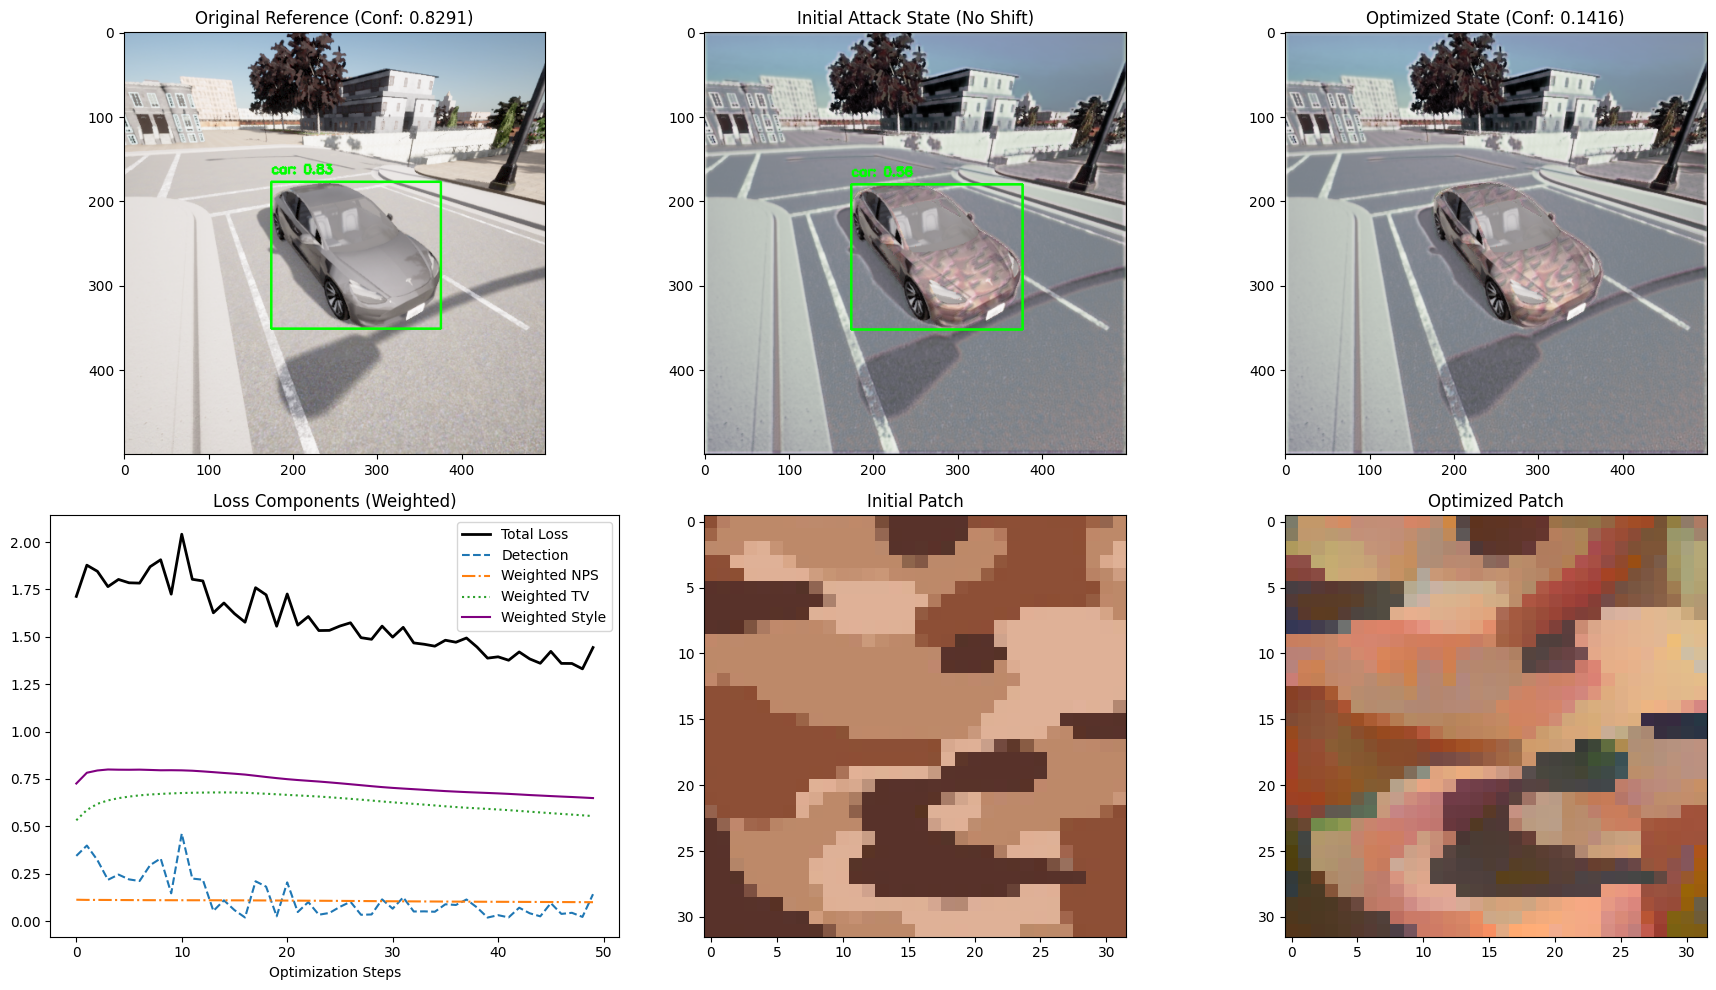

In [ ]:
import tensorflow as tf
import numpy as np
import os
import cv2
from glob import glob
import matplotlib.pyplot as plt
import pandas as pd

DATASET_FOLDER = 'sample_dataset'
METADATA_CSV = os.path.join(DATASET_FOLDER, 'metadata.csv')

SAMPLE_IDX = 2468

MODEL_PATH_RENDERER = 'models/k3_100epch_wo_custom_loss_model.h5'

MODEL_PATH_YOLO = 'yolov8n_saved_model'

IMG_SIZE = (500, 500)

YOLO_SIZE = (640, 640)

TRAINING_STEPS = 50

TEX_RES = 32 # higher resolution for style transfer
TEX_UPSCALE_RES = 256 # upscale size for rendering

INITIAL_TEX_PATH = 'textures/camo_muddy.png'
STYLE_IMAGE_PATH = 'textures/camo_muddy.png'

ATTACK_MODE = 'hide' # 'misclassification' or 'hide'

DETECTION_WEIGHT = 1.0
TV_WEIGHT = 5.0
NPS_WEIGHT = 1.0
STYLE_WEIGHT = 0.1
LEARNING_RATE = 0.01

NPS_DIM = 5

CLASSES = {
    0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus',
    6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant',
    11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat',
    16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear',
    22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag',
    27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard',
    32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove',
    36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle',
    40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl',
    46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli',
    51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake',
    56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table',
    61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard',
    67: 'cell phone', 68: 'microwave', 69: 'oven', 70: 'toaster', 71: 'sink',
    72: 'refrigerator', 73: 'book', 74: 'clock', 75: 'vase', 76: 'scissors',
    77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'
}

# generate a palette of printable colors
def generate_generic_printer_palette(n_per_channel):
    grid_1d = tf.linspace(0.05, 0.95, n_per_channel)
    r, g, b = tf.meshgrid(grid_1d, grid_1d, grid_1d)
    colors = tf.reshape(tf.stack([r, g, b], axis=-1), [-1, 3])
    max_channel = tf.reduce_max(colors, axis=1)
    min_channel = tf.reduce_min(colors, axis=1)
    saturation = max_channel - min_channel
    mask = saturation < 0.9
    colors = tf.boolean_mask(colors, mask)
    return colors

PRINTABLE_COLORS = generate_generic_printer_palette(NPS_DIM)

df_meta = pd.read_csv(METADATA_CSV)

# setup rendering, yolo and vgg models
renderer_model = tf.keras.models.load_model(MODEL_PATH_RENDERER, compile=False) # rendering model

yolo_loaded = tf.saved_model.load(MODEL_PATH_YOLO) # yolo model for detection loss
yolo_infer = yolo_loaded.signatures['serving_default']

vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet') # VGG19 for Style Loss
vgg.trainable = False
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']
style_outputs = [vgg.get_layer(name).output for name in style_layers]
style_extractor = tf.keras.Model([vgg.input], style_outputs)

def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1] * input_shape[2], tf.float32)
    return result / num_locations


target_raw = tf.io.read_file(STYLE_IMAGE_PATH)
target_decoded = tf.image.decode_png(target_raw, channels=3)
target_float = tf.image.convert_image_dtype(target_decoded, tf.float32)
target_resized = tf.image.resize(target_float, [TEX_UPSCALE_RES, TEX_UPSCALE_RES])
target_style_img = tf.expand_dims(target_resized, 0)


initial_raw = tf.io.read_file(INITIAL_TEX_PATH)
initial_decoded = tf.image.decode_png(initial_raw, channels=3)
initial_float = tf.image.convert_image_dtype(initial_decoded, tf.float32)
initial_resized = tf.image.resize(initial_float, [TEX_UPSCALE_RES, TEX_UPSCALE_RES])
initial_style_img = tf.expand_dims(initial_resized, 0)

target_vgg_input = tf.keras.applications.vgg19.preprocess_input(target_style_img * 255.0)
target_features = style_extractor(target_vgg_input)
TARGET_GRAMS = [gram_matrix(feat) for feat in target_features]


def load_dataset_sample(idx):
    row = df_meta.iloc[idx]
    base_name = str(row['filename']).zfill(5)
    
    def prep_img(folder, ext):
        p = os.path.join(DATASET_FOLDER, folder, f"{base_name}{ext}")
        if not os.path.exists(p):
            p = glob(os.path.join(DATASET_FOLDER, folder, f"{base_name}.*"))[0]
        img = tf.image.decode_image(tf.io.read_file(p), channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        return tf.image.resize(img, IMG_SIZE)

    ref = prep_img('reference', '.png')
    mask = prep_img('masks', '.png')
    overlay = prep_img('overlays', '.png')
    trans = np.array([row['distance'], row['pitch'], row['yaw']], dtype=np.float32)
    return ref, mask, overlay, trans


# Repeated texture projection functions
def calc_transforms_tf(pitch, yaw): # needs changing if adaresh dataset is only 1 pitch ################################################
    yaw_diff = ((yaw + 45.0) % 90.0) - 45.0
    cond_front = tf.logical_and(yaw > 145.0, yaw < 215.0)
    
    mid_p = tf.where(cond_front, -pitch, pitch)
    mid_y = tf.where(cond_front, -yaw_diff, 0.0)
    mid_r = tf.where(cond_front, 0.0, -yaw_diff)

    low_cond = pitch < 15.0
    p = tf.where(low_cond, pitch, mid_p)
    y = tf.where(low_cond, 0.0, mid_y)
    r = tf.where(low_cond, -yaw_diff, mid_r)

    top_cond = pitch > 35.0
    p = tf.where(top_cond, -pitch, p)
    y = tf.where(top_cond, -yaw_diff, y)
    r = tf.where(top_cond, 0.0, r)
    return p, y, r

def get_rotation_matrix_tf(pitch, yaw, roll):
    deg2rad = np.pi / 180.0
    p = pitch * deg2rad
    y = yaw * deg2rad
    r = roll * deg2rad
    rot_pitch = tf.stack([[1.0, 0.0, 0.0], [0.0, tf.cos(p), -tf.sin(p)], [0.0, tf.sin(p),  tf.cos(p)]])
    rot_roll = tf.stack([[tf.cos(r), 0.0, tf.sin(r)], [0.0, 1.0, 0.0], [-tf.sin(r), 0.0, tf.cos(r)]])
    rot_yaw = tf.stack([[tf.cos(y), -tf.sin(y), 0.0], [tf.sin(y),  tf.cos(y), 0.0], [0.0, 0.0, 1.0]])
    return tf.matmul(rot_pitch, tf.matmul(rot_roll, rot_yaw))

# Loss releated functions
def calculate_tv(texture):
    raw_tv = tf.reduce_sum(tf.image.total_variation(texture))
    num_elements = tf.cast(tf.size(texture), tf.float32)
    normalized_tv = raw_tv / num_elements
    return normalized_tv

def calculate_nps(texture):
    pixels = tf.reshape(texture, [-1, 3])
    pixels_exp = tf.expand_dims(pixels, 1)
    palette_exp = tf.expand_dims(PRINTABLE_COLORS, 0)
    distances = tf.sqrt(tf.reduce_sum(tf.square(pixels_exp - palette_exp), axis=-1) + 1e-8)
    min_distances = tf.reduce_min(distances, axis=1)
    return tf.reduce_mean(min_distances)

def calculate_style_loss(texture):
    tex_resized = tf.image.resize(texture, [TEX_UPSCALE_RES, TEX_UPSCALE_RES], method='bilinear')
    tex_expanded = tf.expand_dims(tex_resized, 0)
    tex_vgg_input = tf.keras.applications.vgg19.preprocess_input(tex_expanded * 255.0)
    texture_features = style_extractor(tex_vgg_input)
    
    style_loss = tf.add_n([
        tf.reduce_mean(tf.square(gram_matrix(tex_feat) - target_gram))
        for tex_feat, target_gram in zip(texture_features, TARGET_GRAMS)
    ])
    return style_loss / len(style_layers)


def calculate_custom_loss(yolo_output, texture_variable):
    style_normalise = 1e-9

    # Vehicle class IDs
    VEHICLE_CLASS_IDS = [2, 7, 5]
    all_class_scores = yolo_output[0, 4:, :]

    # ---- Vehicle scores ----
    vehicle_class_scores = tf.gather(all_class_scores, VEHICLE_CLASS_IDS, axis=0)
    vehicle_scores = tf.reduce_max(vehicle_class_scores, axis=0)


    if ATTACK_MODE == 'misclassification':
        # Non-vehicle scores
        num_classes = tf.shape(all_class_scores)[0]
        all_class_indices = tf.range(num_classes)

        # Mask out vehicle classes
        non_vehicle_mask = tf.reduce_all(
            tf.not_equal(
                tf.expand_dims(all_class_indices, 1),
                tf.constant(VEHICLE_CLASS_IDS, dtype=all_class_indices.dtype)
            ),
            axis=1
        )
        non_vehicle_class_scores = tf.boolean_mask(all_class_scores, non_vehicle_mask, axis=0)
        non_vehicle_scores = tf.reduce_max(non_vehicle_class_scores, axis=0)

        # Minimize the worst case (one most confident its a car)
        anchor_margins = vehicle_scores - non_vehicle_scores
        detection_loss = tf.reduce_max(anchor_margins)

    else:
        detection_loss = tf.reduce_max(vehicle_scores)

    
    weighted_detection = DETECTION_WEIGHT * detection_loss
    weighted_tv = TV_WEIGHT * calculate_tv(texture_variable)
    weighted_nps = NPS_WEIGHT * calculate_nps(texture_variable)
    weighted_style = STYLE_WEIGHT * style_normalise * calculate_style_loss(texture_variable)
    
    total_loss = weighted_detection + weighted_tv + weighted_nps + weighted_style
    
    # return actual loss & weighted components for logging
    return total_loss, detection_loss, weighted_tv, weighted_nps, weighted_style


# rendering related functions
def bilinear_sampler_tf(img, x, y):
    H_f, W_f = tf.cast(tf.shape(img)[0], tf.float32), tf.cast(tf.shape(img)[1], tf.float32)
    x, y = tf.clip_by_value(x, 0.0, W_f - 1.001), tf.clip_by_value(y, 0.0, H_f - 1.001)
    x0, y0 = tf.cast(tf.floor(x), tf.int32), tf.cast(tf.floor(y), tf.int32)
    x1, y1 = x0 + 1, y0 + 1
    
    Ia = tf.gather_nd(img, tf.stack([y0, x0], axis=-1))
    Ib = tf.gather_nd(img, tf.stack([y1, x0], axis=-1))
    Ic = tf.gather_nd(img, tf.stack([y0, x1], axis=-1))
    Id = tf.gather_nd(img, tf.stack([y1, x1], axis=-1))
    
    wa = tf.expand_dims((tf.cast(x1, tf.float32) - x) * (tf.cast(y1, tf.float32) - y), -1)
    wb = tf.expand_dims((tf.cast(x1, tf.float32) - x) * (y - tf.cast(y0, tf.float32)), -1)
    wc = tf.expand_dims((x - tf.cast(x0, tf.float32)) * (tf.cast(y1, tf.float32) - y), -1)
    wd = tf.expand_dims((x - tf.cast(x0, tf.float32)) * (y - tf.cast(y0, tf.float32)), -1)
    return tf.add_n([wa*Ia, wb*Ib, wc*Ic, wd*Id])

@tf.function
def render_texture_tf(texture, pitch, yaw, roll, distance, uv_scale=100.0, shift_u=0.0, shift_v=0.0):
    out_h, out_w = IMG_SIZE
    f = 500.0
    cx, cy = out_w / 2.0, out_h / 2.0
    
    high_res_tex = tf.image.resize(texture, [TEX_UPSCALE_RES, TEX_UPSCALE_RES], method='nearest')
    R = get_rotation_matrix_tf(pitch, yaw, roll)
    plane_normal = R[:, 2] 

    pixels_per_meter = 100.0 
    center_dist_units = distance * pixels_per_meter
    plane_point = tf.constant([0.0, 0.0, 0.0]) + (plane_normal * center_dist_units)

    grid_x, grid_y = tf.meshgrid(tf.range(out_w), tf.range(out_h))
    rx, ry, rz = tf.cast(grid_x, tf.float32) - cx, tf.cast(grid_y, tf.float32) - cy, tf.ones_like(tf.cast(grid_x, tf.float32)) * f
    ray_dir = tf.stack([rx, ry, rz], axis=-1)

    camera_pos = tf.constant([0.0, 0.0, -f])
    numerator = tf.tensordot(plane_point - camera_pos, plane_normal, axes=1)
    denominator = tf.where(tf.abs(tf.tensordot(ray_dir, plane_normal, axes=1)) < 1e-5, 1e-5, tf.tensordot(ray_dir, plane_normal, axes=1))
    t = numerator / denominator
    hit_point = camera_pos + (ray_dir * tf.expand_dims(t, -1))

    p_local = tf.reshape(tf.matmul(tf.reshape(hit_point - plane_point, [-1, 3]), R), [out_h, out_w, 3])
    
    u = (p_local[:, :, 0] / uv_scale) + shift_u
    v = (p_local[:, :, 1] / uv_scale) + shift_v
    
    u, v = tf.math.floormod(u, 1.0), tf.math.floormod(v, 1.0)
    
    tex_h, tex_w = tf.cast(tf.shape(high_res_tex)[0], tf.float32), tf.cast(tf.shape(high_res_tex)[1], tf.float32)
    output = bilinear_sampler_tf(high_res_tex, u * (tex_w - 1.0), v * (tex_h - 1.0))
    
    return tf.where(tf.expand_dims(t > 0.0, -1), output, tf.zeros_like(output))


# Yolo visulization
def draw_yolo_results(image_tf, yolo_output, conf_thresh=0.25):
    img = (image_tf.numpy() * 255).astype(np.uint8).copy()
    output = np.transpose(yolo_output.numpy()[0])
    
    boxes, confs, class_ids = [], [], []
    for row in output:
        scores = row[4:]
        cls_id = np.argmax(scores)
        score = scores[cls_id]
        if score > conf_thresh:
            scale = tf.constant([
                IMG_SIZE[1] / YOLO_SIZE[1],
                IMG_SIZE[0] / YOLO_SIZE[0],
                IMG_SIZE[1] / YOLO_SIZE[1],
                IMG_SIZE[0] / YOLO_SIZE[0],
            ], dtype=tf.float32)

            cx, cy, w, h = row[:4] * scale
            boxes.append([int(cx - w/2), int(cy - h/2), int(w), int(h)])
            confs.append(float(score))
            class_ids.append(cls_id)

    indices = cv2.dnn.NMSBoxes(boxes, confs, conf_thresh, 0.45)
    if len(indices) > 0:
        for i in indices.flatten():
            bx, by, bw, bh = boxes[i]
            cv2.rectangle(img, (bx, by), (bx+bw, by+bh), (0, 255, 0), 2)
            cv2.putText(img, f"{CLASSES.get(class_ids[i], 'obj')}: {confs[i]:.2f}", (bx, by-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img


# Training
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Initialize from the initial image
init_img = tf.image.resize(initial_style_img, [TEX_RES, TEX_RES])
tf_texture = tf.Variable(init_img[0], dtype=tf.float32)



@tf.function
def train_step(ref_img, mask_img, overlay_img, trans_num_tf, shift_u, shift_v):
    dist, pitch, yaw = trans_num_tf[0], trans_num_tf[1], trans_num_tf[2]
    p, y, r = calc_transforms_tf(pitch, yaw)
    
    with tf.GradientTape() as tape:
        rendered = render_texture_tf(tf_texture, p, y, r, dist, shift_u=shift_u, shift_v=shift_v)
        mask_bool = tf.reduce_max(mask_img, axis=-1, keepdims=True) > 0.1
        tex_masked = tf.where(mask_bool, rendered, tf.zeros_like(rendered))
        
        renderer_out = renderer_model([tf.expand_dims(ref_img, 0), tf.expand_dims(tex_masked, 0)], training=False)[0]
        
        overlay_bool = tf.reduce_max(overlay_img, axis=-1, keepdims=True) > 0.05
        adv_img = tf.where(overlay_bool, ref_img, renderer_out)
        
        yolo_in = tf.image.resize(tf.expand_dims(adv_img, 0), YOLO_SIZE)
        yolo_out = yolo_infer(images=yolo_in)['output_0']
        
        total_loss, det_loss, w_tv, w_nps, w_style = calculate_custom_loss(yolo_out, tf_texture)
        
    optimizer.apply_gradients(zip(tape.gradient(total_loss, [tf_texture]), [tf_texture]))

    # Constrain the texture back to valid RGB values after the update
    tf_texture.assign(tf.clip_by_value(tf_texture, 0.0, 1.0))

    
    # Return the WEIGHTED values
    return total_loss, det_loss, w_tv, w_nps, w_style, adv_img, yolo_out




# Optimization loop
ref, mask, overlay, trans = load_dataset_sample(SAMPLE_IDX)
print("Starting optimization...")

ref_yolo_in = tf.image.resize(tf.expand_dims(ref, 0), YOLO_SIZE)
ref_yolo_out = yolo_infer(images=ref_yolo_in)['output_0']
ref_max_conf = tf.reduce_max(tf.stack([ref_yolo_out[0, 4 + c, :] for c in [2, 7, 5]], axis=0))

trans_num_tf = tf.constant(trans[:3].astype(np.float32))

p_init, y_init, r_init = calc_transforms_tf(trans_num_tf[1], trans_num_tf[2])
init_rendered = render_texture_tf(tf_texture, p_init, y_init, r_init, trans_num_tf[0], shift_u=0.0, shift_v=0.0)
init_mask_bool = tf.reduce_max(mask, axis=-1, keepdims=True) > 0.1
init_tex_masked = tf.where(init_mask_bool, init_rendered, tf.zeros_like(init_rendered))
init_renderer = renderer_model([tf.expand_dims(ref, 0), tf.expand_dims(init_tex_masked, 0)], training=False)[0]
init_overlay_bool = tf.reduce_max(overlay, axis=-1, keepdims=True) > 0.05
init_adv = tf.where(init_overlay_bool, ref, init_renderer)
init_yolo = yolo_infer(images=tf.image.resize(tf.expand_dims(init_adv, 0), YOLO_SIZE))['output_0']

history = {'total': [], 'det': [], 'tv': [], 'nps': [], 'style': []}



for step in range(TRAINING_STEPS):
    rand_shift_u = tf.random.uniform(shape=[], minval=0.0, maxval=1.0)
    rand_shift_v = tf.random.uniform(shape=[], minval=0.0, maxval=1.0)
    
    t_loss, d_loss, w_tv, w_nps, w_style, cur_adv, cur_yolo = train_step(
        ref, mask, overlay, trans_num_tf, rand_shift_u, rand_shift_v
    )
    
    history['total'].append(t_loss.numpy())
    history['det'].append(d_loss.numpy())
    history['tv'].append(w_tv.numpy())
    history['nps'].append(w_nps.numpy())
    history['style'].append(w_style.numpy())
    
    print(f"Step {step:3d} | Total: {t_loss.numpy():.4f} | Det: {d_loss.numpy():.4f} | W-NPS: {w_nps.numpy():.4f} | W-TV: {w_tv.numpy():.4f} | W-Style: {w_style.numpy():.4f}")

# Display results
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(draw_yolo_results(ref, ref_yolo_out))
plt.title(f"Original Reference (Conf: {ref_max_conf.numpy():.4f})")

plt.subplot(2, 3, 2)
plt.imshow(draw_yolo_results(init_adv, init_yolo))
plt.title("Initial Attack State (No Shift)")

plt.subplot(2, 3, 3)
plt.imshow(draw_yolo_results(cur_adv, cur_yolo))
plt.title(f"Optimized State (Conf: {d_loss.numpy():.4f})")

plt.subplot(2, 3, 4)
plt.plot(history['total'], label='Total Loss', color='black', linewidth=2)
plt.plot(history['det'], label='Detection', linestyle='--')
plt.plot(history['nps'], label='Weighted NPS', linestyle='-.')
plt.plot(history['tv'], label='Weighted TV', linestyle=':')
plt.plot(history['style'], label='Weighted Style', linestyle='-', color='purple')
plt.title("Loss Components (Weighted)")
plt.xlabel("Optimization Steps")
plt.legend()

# show initial texture
plt.subplot(2, 3, 5)
plt.imshow(tf.clip_by_value(init_img[0], 0.0, 1.0).numpy())
plt.title("Initial Patch")

plt.subplot(2, 3, 6)
plt.imshow(tf.clip_by_value(tf_texture, 0.0, 1.0).numpy())
plt.title("Optimized Patch")


plt.tight_layout()
plt.show()